In [1]:
from viz import plot_snapshots

from project import load_config, solve_heat_equation, train_pinn
from project import load_config, generate_training_data
cfg = load_config("../config.yaml")

x, y, t, T_fdm, sensor_data = generate_training_data(cfg)
import jax.numpy as jnp
import numpy as np

import jax
import jax.numpy as jnp

In [21]:
cfg = load_config("../config.yaml")

In [35]:
x, y, t, T_fdm = solve_heat_equation(cfg)

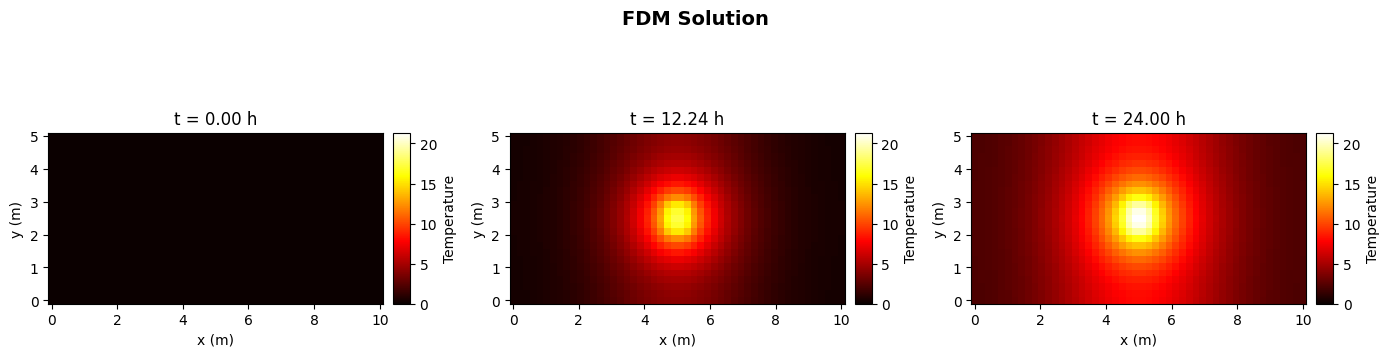

In [33]:
plot_snapshots(
    x,
    y,
    t,
    T_fdm,
    title="FDM Solution",
    show_interactively=True,
)

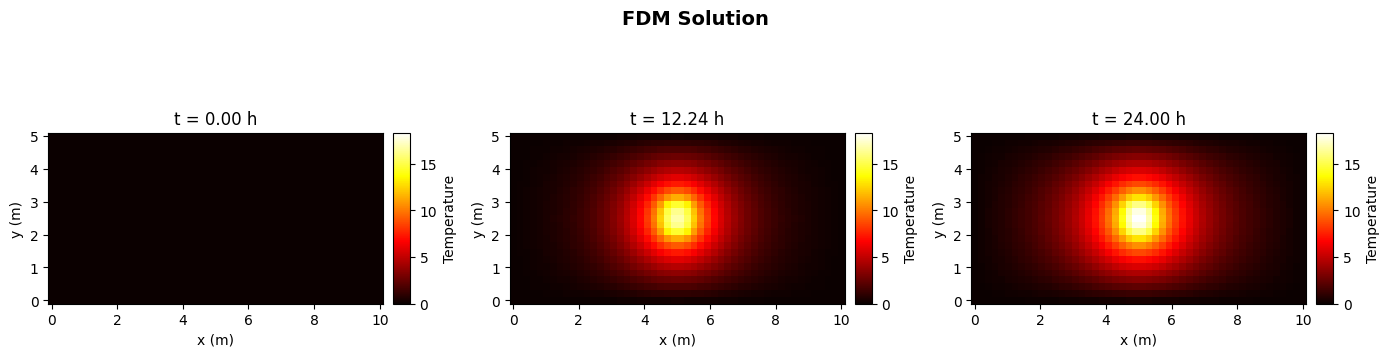

In [36]:
plot_snapshots(
    x,
    y,
    t,
    T_fdm,
    title="FDM Solution",
    show_interactively=True,)

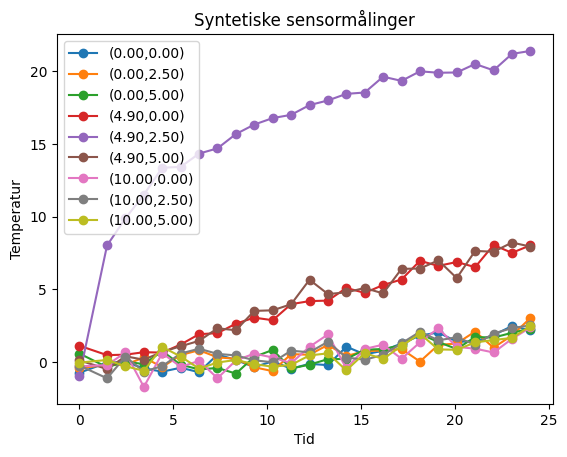

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from project.data import generate_training_data


x, y, t, T_fdm, sensor_data = generate_training_data(cfg)

sd = np.array(sensor_data)
xs, ys, ts, temps = sd[:, 0], sd[:, 1], sd[:, 2], sd[:, 3]

plt.figure()
for (sx, sy) in np.unique(sd[:, :2], axis=0):
    mask = (xs == sx) & (ys == sy)
    plt.plot(ts[mask], temps[mask], marker="o", label=f"({sx:.2f},{sy:.2f})")

plt.xlabel("Tid")
plt.ylabel("Temperatur")
plt.title("Syntetiske sensormålinger")
plt.legend()
plt.show()

In [2]:
pinn_params, losses = train_pinn(sensor_data, cfg)

alpha = jnp.exp(pinn_params["log_alpha"])[0]
k     = jnp.exp(pinn_params["log_k"])[0]
h     = jnp.exp(pinn_params["log_h"])[0]
power = jnp.exp(pinn_params["log_power"])[0]

print("alpha:", float(alpha))
print("k    :", float(k))
print("h    :", float(h))
print("power:", float(power))


Training PINN: 100%|██████████| 5000/5000 [07:15<00:00, 11.48it/s]


alpha: 0.01877954974770546
k    : 0.10566136986017227
h    : 0.36989328265190125
power: 2.008427619934082
